In [3]:
import numpy as np
from uncertainties import ufloat
from uncertainties import unumpy as unp
import math
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Latex, Markdown, HTML
from scipy.stats import linregress
from uncertainties.umath import sqrt


$$\text{Anna Lechner, Paula Erhard}$$

# PW11 - Elektrische Schwingungen

## Freie Schwingungen

### versuchsaufbau und Durchführung

Ein LC-Schwingkreis mit einstellbarem Dämpfungswiderstand wurde aufgebaut und über einen Einkoppelkondensator durch eine Rechteckspannung impulsartig angeregt. Nach der Anregung schwingt der Kreis frei, wobei die Kondensatorspannung $U_C(t)$ mit dem Oszilloskop gemessen wurde. Aus den Maxima der abklingenden Schwingung wurden Periodendauer und Amplituden bestimmt.

### Wichtige Formeln und Zusammenhänge

Die gedämpfte Kreisfrequenz ergibt sich aus $\omega_d = \frac{2\pi}{T_d}$  
Der Amplitudenabfall folgt  $ A(t) = A_0 e^{-\delta t} $, wobei die Dämpfungskonstante aus $ \ln\!\left(\frac{A_i}{A_0}\right) = -\delta t_i $ bestimmt wurde. Die Eigenfrequenz berechnet sich zu $ \omega_0 = \sqrt{\omega_d^2 + \delta^2} $ mit $ \delta = \frac{R}{2L} $ und $ \omega_0 = \frac{1}{\sqrt{LC}} $ konnten Widerstand und Kapazität bestimmt werden.



### Verwendete Geräte



### Auswertung

In [ ]:
# 1. Experiment: freie Schwingungen

L = ufloat(, )                  #Induktivität Spule [H]; an Spule angegeben
R_D = ufloat(3, )               #zusätzlicher Dämpfungswiderstand [Ohm]

# 1a Periodendauer und omega_d (Kreisfrequenz)
#minimale Dämpfung
delta_t1 =                       #[s]; mit CURSOR im DSO messen?
Zahl1 = ufloat(, 1)              #wie viele Perioden (zählen)
T1 = delta_t1/Zahl1                #Periodendauer [s]

omega_d1 = (2*np.pi)/T1           #Kreisfrequenz [rad/s]

display(Markdown(rf"$$\omega_d = {omega_d1:.3f} ~ \mathrm rad/s$$"))

# #mit Dämpfungswiderstand
# delta_t2 =                       #[s]; mit CURSOR im DSO messen?
# Zahl2 = ufloat(, 1)              #wie viele Perioden (zählen)
# T2 = delta_t2/Zahl2                #Periodendauer [s]

# omega_d2 = (2*np.pi)/T2           #Kreisfrequenz [rad/s]

# display(Markdown(rf"$$\omega_d2 = {omega_d2:.3f} ~ \mathrm rad/s$$"))


# 1b Amplituden und Bestimmung delta (Dämpfungskonstante)
#minimale Dämpfung
A01 =                            #1. Amplitude/Ausgangswert
A_i1 = unp.uarray([], )          #6-10 weitere Amplituden; was ist die Unsicherheit ??
t_i1 = unp.uarray([], )          #zugehörige Zeiten zu den A_i

rat1 = np.log(A_i1/A01)

res1 = linregress(t_i1, rat1)
steigung1 = ufloat(res1.slope, res1.stderr)

delta1 = -steigung1


# #mit Dämpfungswiderstand
# A02 =                            #1. Amplitude/Ausgangswert
# A_i2 = unp.uarray([], )          #6-10 weitere Amplituden; was ist die Unsicherheit ??
# t_i2 = unp.uarray([], )          #zugehörige Zeiten zu den A_i

# rat2 = np.log(A_i2/A02)

# res2 = linregress(t_i2, rat2)
# steigung2 = ufloat(res2.slope, res2.stderr)

# delta2 = -steigung2

#ergebnisse punkt 2 plotten und ausgeben
plt.figure()
plt.plot(t_i1, rat1, 'o', markersize=3, label="ln(A0/A_i) bei minimaler Dämpfung", color="orange")
plt.plot(t_i1, (t_i1*res1.slpoe)+res1.intercept, '-', label=rf"lineare Regression bei minimaler Dämpfung, r² = {res1.rvalue**2:.3f}", color="red")
#plt.plot(t_i2, rat2, 'o', markersize=3, label="ln(A0/A_i) mit zusätzlichem Dämpfungswiderstand R_D", color="blue")
#plt.plot(t_i2, (t_i2*res2.slpoe)+res2.intercept, '-', label=rf"lineare Regression mit zusätzlichem Dämpfungswiderstand R_D, r² = {res2.rvalue**2:.3f}", color="green")
plt.title("Zusammenhang von Dämpfung und Amplidtuden")
plt.xlabel("Dämpfung [1/s]")
plt.ylabel("Zeit [s]")
plt.legend()
plt.grid(True)
plt.show()

display(Markdown(rf"Die Steigung der linearen Regression bei minimaler Dämpfung ist: {steigung1}"))
#display(Markdown(rf"Die Steigung der linearen Regression mit einem zusätlichen Dämpfungswiderstand R_D ist: {steigung2}"))

display(Markdown(rf"$$\delta = {delta1} ~ \mathrm 1/s$$"))
#display(Markdown(rf"$$\delta_2 = {delta2} ~ \mathrm 1/s$$"))


# 1c Eigenfrequenz
#minimale Dämpfung
omega_01 = unp.sqrt(omega_d1**2 + delta1**2)            #Eigenfrequenz [rad/s]
unterschied1 = omega_01 - omega_d1                      #Frequenzverstimmung

display(Markdown(rf"$$\omega_0 = {omega_01} ~ \mathrm rad/s$$"))
display(Markdown(rf"Die Frequenzverstimmung ist: {unterschied1} und somit (nicht) vernachlässigbar"))

# #mit Dämpfungswiderstand
# omega_02 = unp.sqrt(omega_d2**2 + delta2**2)            #Eigenfrequenz [rad/s]
# unterschied2 = omega_02 - omega_d2                      #Frequenzverstimmung

# display(Markdown(rf"$$\omega_02 = {omega_02} ~ \mathrm rad/s$$"))
# display(Markdown(rf"Die Frequenzverstimmung ist: {unterschied2} und somit (nicht) vernachlässigbar"))


# 1d Bestimmung R_L und C (minimale Dämpfung)
R_L = 2 * L * delta1                    #[Ohm]
C = 1 /(omega_01**2 * L)                #[F]

display(Markdown(rf"$$R_L = {R_L} ~ \mathrm \Omega$$"))
display(Markdown(rf"$$C = {C} ~ \mathrm F$$"))


# 2a Fotos bei veränderung mit Dämpfung


# 2b aperiodischer Grenzfall (mit Stellwiderstand)
R_D_gemessen = ufloat(, )               #[Ohm], empirisch ermitteln am Stellwiderstand (wie?)
R_gemessen = R_D_gemessen + R_L         #[0hm], R_D + R_L

omega0 = unp.sqrt(1/(L*C))
R = 2 * L * omega0                      #berechnet, aperiodischer Grenzfall: delta = omega0

display(Markdown(rf"$$R_{gemessen} = {R_gemessen} ~ \mathrm \Omega$$"))
display(Markdown(rf"$$R = {R} ~ \mathrm \Omega$$"))



wertefreieschwingung1 = np.array([omega_01, delta1])            #für 2. Experiment

### Diskussion

## Erzwungene Schwingungen

### Versuchsaufbau und Durchführung

Der Schwingkreis wurde mit einer sinusförmigen Wechselspannung variabler Frequenz angeregt. Für jede Frequenz wurde die Amplitude der Kondensatorspannung $U_{C0}(\omega)$ gemessen und als Resonanzkurve dargestellt.

### Wichtige Formeln und Zusammenhänge

Die Resonanzkurve folgt  $ U_{C0}(\omega) = U_0 \frac{C'}{C} \frac{\omega^2}{\sqrt{(\omega_0^2-\omega^2)^2 + 4\delta^2\omega^2}} $. Aus dem Maximum wurde die Resonanzfrequenz $\omega_{\text{max}}$ bestimmt. Die Resonanzbreite  $ \Delta \omega = 2\delta $ ergibt sich bei $ U_{C0} = \frac{U_{\text{max}}}{\sqrt{2}} $. Der Gütefaktor ist $ Q = \frac{\omega_0}{2\delta} $. Die Phasenverschiebung wurde aus der Zeitverschiebung der Signale bestimmt: $ \varphi = \omega \Delta t $

### Verwendete Geräte



### Auswertung

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_727/744302736.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.scatter(x1, Uwurzel2, marker="o", color='red', s=100, label="$U_{max} / \sqrt{2}$")


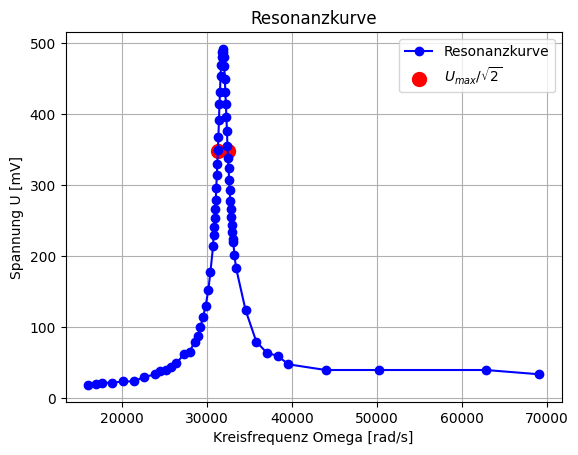

,Kreisfrequenz [Rad/s],Phasenverschiebung [Rad]
0,omega_max,0.84
1,"0,8 omega_max",0.00
2,"1,2 omega_max",0.09


$$ \omega_0 = 5047.77 ~ \mathrm rad/s$$

$$ \delta = 582.93 ~ \mathrm 1/s$$

$$Q = 4.27$$

/tmp/ipykernel_727/744302736.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.scatter(x1, Uwurzel2, marker="o", color='red', s=100, label="$U_{max} / \sqrt{2}$")


NameError: name 'wertefreieschwingung1' is not defined

In [ ]:
# 2. Experiment: erzwungene Schwingung

# 1. Resonanzkurve
UC0 = np.array([19, 20, 22, 22, 24, 24, 30, 34, 38, 40, 44, 50, 62, 66, 80, 88, 100, 114, 130, 152, 178, 214, 230, 242, 254, 266, 280, 296, 314, 330, 350, 368, 392, 414, 432, 454, 470, 480, 488, 492, 488, 480, 468, 450, 432, 414, 396, 376, 356, 338, 324, 308, 294, 278, 266, 256, 244, 234, 225, 220, 202, 184, 124, 80, 64, 60, 48, 40, 40, 40, 34]) # [mV]
f = np.array([2550, 2700, 2800, 3000, 3200, 3400, 3600, 3800, 3900, 4000, 4100, 4200, 4350, 4450, 4550, 4600, 4650, 4700, 4750, 4800, 4840, 4890, 4900, 4910, 4920, 4930, 4940, 4950, 4960, 4970, 4980, 4990, 5000, 5010, 5020, 5030, 5040, 5050, 5060, 5070, 5080, 5090, 5100, 5110, 5120, 5130, 5140, 5150, 5160, 5170, 5180, 5190, 5200, 5210, 5220, 5230, 5240, 5250, 5260, 5270, 5290, 5320, 5500, 5700, 5900, 6100, 6300, 7000, 8000, 10000, 11000]) # [Hz]
omega = 2*np.pi*f       #[rad/s]
#omega_max ist ca 4980 Hz

# 2. Phasenverschiebung: aufs Vorzeichen schauen laut Konvention!!
phi_omegamax = 0.84             #[rad]; gemessen am Oszilloskop?
phi_0_8 = 0 
phi_1_2 = 0.09                  #[rad]

phi = np.array([phi_omegamax, phi_0_8, phi_1_2])
name = np.array(["omega_max", "0,8 omega_max", "1,2 omega_max"])

# eigenfrequenz, dämpfung, gütefaktor
Umax = 492                      #[mV]
imax = np.argmax(UC0)           #index von U_max ?
Uwurzel2 = (1/np.sqrt(2))*Umax

y1 = UC0[:imax+1]               #Werte bis max
omega1 = omega[:imax+1]
y2 = UC0[imax:]                 #Werte ab max
omega2 = omega[imax:]
x1 = np.interp(Uwurzel2, y1, omega1)
x2 = np.interp(Uwurzel2, y2[::-1], omega2[::-1])

omegamax = 4980 #gemessen
deltax = x2 - x1
delta_4 = deltax/2
Q = omegamax/deltax             #Gütefaktor
omega0 = np.sqrt((omegamax)**2 + 2*((delta_4)**2))          #[rad/s] Eigenschwingung

werteerzwungeneschwingung = np.array([omega0, delta_4])

plt.figure()
plt.plot(omega, UC0, marker="o", label="Resonanzkurve", color='blue')
plt.scatter(x1, Uwurzel2, marker="o", color='red', s=100, label="$U_{max} / \sqrt{2}$")
plt.scatter(x2, Uwurzel2, marker="o", color='red', s=100)
plt.xlabel("Kreisfrequenz Omega [rad/s]")
plt.ylabel("Spannung U [mV]")
plt.title("Resonanzkurve")
plt.legend()
plt.grid(True)
plt.show()


tabelle = {
    "Kreisfrequenz [Rad/s]": name,
    "Phasenverschiebung [Rad]": phi
}
df = pd.DataFrame(tabelle)
display(df)

display(Markdown(rf"$$ \omega_0 = {omega0:.2f} ~ \mathrm rad/s$$"))
display(Markdown(rf"$$ \delta = {delta_4:.2f} ~ \mathrm 1/s$$"))
display(Markdown(rf"$$Q = {Q:.2f}$$"))

vergleichstabelle = {
    "Freie Schwingung": wertefreieschwingung1,
    "Erzwungene Schwingung": werteerzwungeneschwingung
}
df_ = pd.DataFrame(vergleichstabelle)
display(df_)

### Diskussion